In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np

col = 'mutation_coverage'

pitest_figures_out = '../../generated/figures/pitest'
pitest_data_path = '../../generated/code-analysis/pitest.csv'

if not os.path.exists(pitest_data_path):
    raise FileNotFoundError(f"Le fichier {pitest_data_path} n'existe pas. Exécutez d'abord le notebook '../arrange data/Pitest.ipynb' avant.")

df_pitest = pd.read_csv(pitest_data_path)
df_pitest = df_pitest.drop(index = 0)
df_pitest

,user,game_mode,survived,killed,mutants_count,mutation_coverage
1,0d271530-be17-4538-bf04-dde3c6069b5f,SOLO,271,26,297,0.087542
2,11555248-3f01-4d1c-9a71-ef7caf9150fa,SOLO,282,15,297,0.050505
3,70c71a91-06a1-4bf4-8e56-f4327b1c8b3f,SOLO,286,11,297,0.037037
4,70e85b5e-92d4-498a-9079-ba881f5b3b82,TEAM,263,34,297,0.114478
5,7234f6dc-a316-4576-8453-6e10d7cf1c3d,SOLO,226,71,297,0.239057
6,84c2c4e6-1c27-4f2c-808b-9e84a7cb257e,SOLO,243,54,297,0.181818
7,960ad9f8-2b83-4526-9cfb-1a59cec049a6,SOLO,268,29,297,0.097643
8,bcec21aa-2246-4ee8-9f2a-3998a5cde697,TEAM,286,11,297,0.037037
9,c27240eb-52c0-4436-aa0f-e7f97a94a725,TEAM,237,60,297,0.202020
10,eda1acdb-c4bb-4425-a39f-4c25a998e739,SOLO,267,30,297,0.101010


# Boxplot

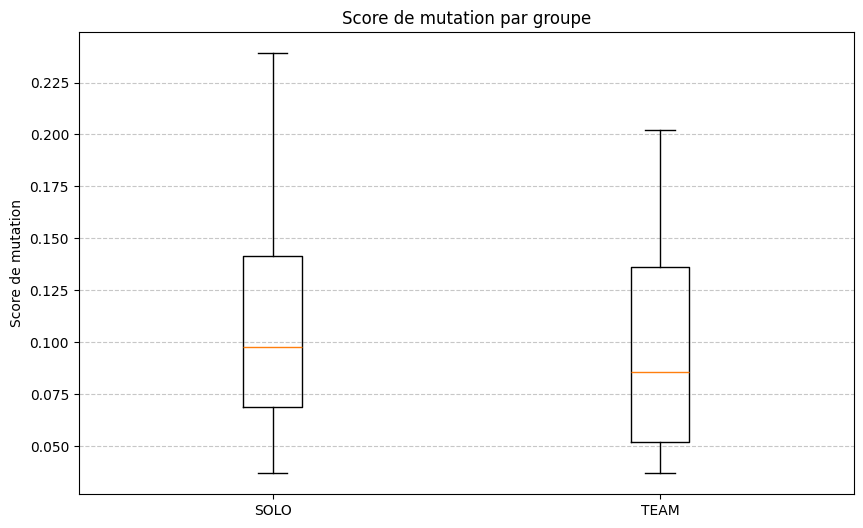

In [4]:
if not os.path.exists(pitest_figures_out):
    os.makedirs(pitest_figures_out)

plt.figure(figsize=(10, 6))
plt.boxplot([
    df_pitest[(df_pitest['game_mode'] == 'SOLO')][col],
    df_pitest[(df_pitest['game_mode'] == 'TEAM')][col]
], tick_labels=['SOLO', 'TEAM'])

plt.title('Score de mutation par groupe')
plt.ylabel('Score de mutation')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{pitest_figures_out}/mutation_score_by_game_mode.pdf")
plt.show()

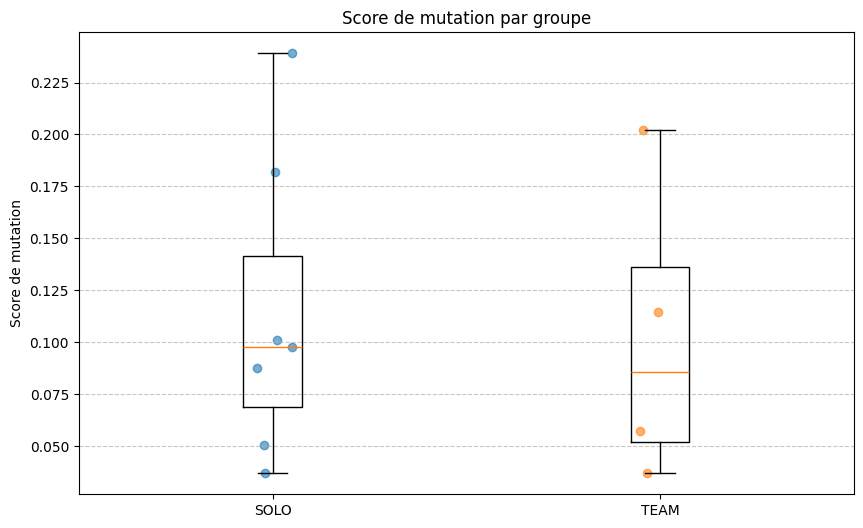

In [11]:


plt.figure(figsize=(10, 6))
plt.boxplot([
    df_pitest[(df_pitest['game_mode'] == 'SOLO')][col],
    df_pitest[(df_pitest['game_mode'] == 'TEAM')][col]
], tick_labels=['SOLO', 'TEAM'])
for i in [1,2]:
    y = df_pitest[df_pitest['game_mode'] == ('SOLO' if i == 1 else 'TEAM')][col]
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6)
plt.title('Score de mutation par groupe')
plt.ylabel('Score de mutation')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{pitest_figures_out}/mutation_score_by_game_mode.pdf")
plt.show()

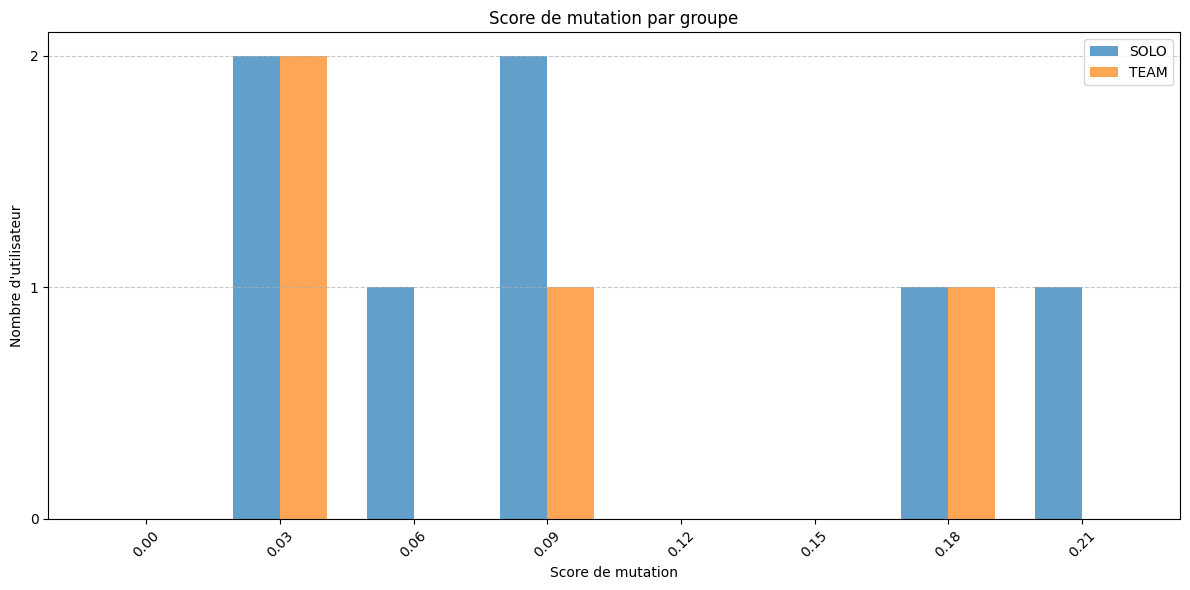

In [16]:
import numpy as np

solo_data = df_pitest[df_pitest['game_mode'] == 'SOLO'][col].dropna()
team_data = df_pitest[df_pitest['game_mode'] == 'TEAM'][col].dropna()

bins = np.arange(0.0, 0.25, 0.03) 

solo_counts, _ = np.histogram(solo_data, bins=bins)
team_counts, _ = np.histogram(team_data, bins=bins)

x = np.arange(len(bins) - 1)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, solo_counts, width, label='SOLO', alpha=0.7)
ax.bar(x + width/2, team_counts, width, label='TEAM', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{b:.2f}" for b in bins[:-1]], rotation=45)
ax.set_xlabel('Score de mutation')
ax.set_ylabel('Nombre d\'utilisateur')
ax.set_title('Score de mutation par groupe')
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # integer y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{pitest_figures_out}/mutation_score_by_game_mode_barplot.pdf")
plt.show()

In [8]:
solo_mean = solo_data.mean()
team_mean = team_data.mean()
print(f"SOLO mean: {solo_mean:.4f}, TEAM mean: {team_mean:.4f}")
team_mean_without_outliers = team_data[team_data < 0.3].mean()
print(f"TEAM mean without outliers: {team_mean_without_outliers:.4f}")

SOLO mean: 0.1135, TEAM mean: 0.1778
TEAM mean without outliers: 0.1027
